In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

In [2]:
import seaborn as sns

In [7]:
car_df = pd.read_csv("data2/1_used_car_prices.csv")
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                961 non-null    object 
 1   age_years            1000 non-null   float64
 2   mileage_km           1000 non-null   float64
 3   engine_type          979 non-null    object 
 4   engine_size_cc       1000 non-null   float64
 5   horsepower           1000 non-null   float64
 6   fuel_efficiency_kml  1000 non-null   float64
 7   accident_count       1000 non-null   float64
 8   color                968 non-null    object 
 9   option_grade         973 non-null    object 
 10  price_krw            1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [8]:
import platform
from matplotlib import rc
if platform.system() == 'Darwin': # masOS
    rc('font', family='AppleGothic')
else:
    rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='engine_type', ylabel='price_krw'>

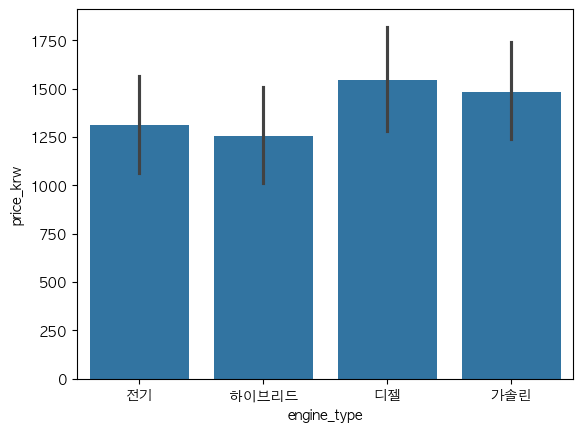

In [9]:
sns.barplot(data=car_df, x='engine_type', y='price_krw')

In [11]:
grouped_price = car_df.groupby(['brand','option_grade'])['price_krw'].mean()
grouped_price

brand  option_grade
A사     고급              1261.629630
       기본              1188.489583
       중급              1314.852632
B사     고급              1539.666667
       기본              1503.191489
       중급              1877.250000
C사     고급              1165.759259
       기본              1924.813559
       중급              1316.819672
D사     고급              1467.735849
       기본              1218.375000
       중급              1019.464286
Name: price_krw, dtype: float64

In [12]:
highest_price_combo = grouped_price.idxmax()
print(highest_price_combo)

('C사', '기본')


In [13]:
car_df.head()

,brand,age_years,mileage_km,engine_type,engine_size_cc,horsepower,fuel_efficiency_kml,accident_count,color,option_grade,price_krw
0,B사,14.0,218413.0,전기,3253.0,333.0,8.6,3.0,검정,고급,100.0
1,D사,11.0,90552.0,하이브리드,3294.0,327.0,8.3,0.0,은색,고급,100.0
2,C사,13.0,178150.0,디젤,3805.0,387.0,4.8,0.0,흰색,중급,100.0
3,NaN,7.0,127044.0,하이브리드,1146.0,110.0,19.2,2.0,기타,고급,100.0
4,A사,2.0,40116.0,디젤,3165.0,340.0,8.9,0.0,은색,고급,3987.0


In [38]:
car_pre = car_df.copy()
mode_option = car_df['option_grade'].mode()[0]

car_pre['option_grade'].fillna(mode_option, inplace=True)

car_pre.drop(['color'], axis=1, inplace=True)

In [39]:
car_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                961 non-null    object 
 1   age_years            1000 non-null   float64
 2   mileage_km           1000 non-null   float64
 3   engine_type          979 non-null    object 
 4   engine_size_cc       1000 non-null   float64
 5   horsepower           1000 non-null   float64
 6   fuel_efficiency_kml  1000 non-null   float64
 7   accident_count       1000 non-null   float64
 8   option_grade         1000 non-null   object 
 9   price_krw            1000 non-null   float64
dtypes: float64(7), object(3)
memory usage: 78.2+ KB


In [40]:
car_df['option_grade'].unique()

array(['고급', '중급', '기본', nan], dtype=object)

In [41]:
car_df['option_grade'].nunique(dropna=False)

4

In [42]:
car_df['option_grade'].value_counts(dropna=False)

option_grade
기본     341
고급     332
중급     300
NaN     27
Name: count, dtype: int64

In [43]:
car_pre['option_grade'].unique()

array(['고급', '중급', '기본'], dtype=object)

In [44]:
car_pre['option_grade'].value_counts()

option_grade
기본    368
고급    332
중급    300
Name: count, dtype: int64

In [45]:
car_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                961 non-null    object 
 1   age_years            1000 non-null   float64
 2   mileage_km           1000 non-null   float64
 3   engine_type          979 non-null    object 
 4   engine_size_cc       1000 non-null   float64
 5   horsepower           1000 non-null   float64
 6   fuel_efficiency_kml  1000 non-null   float64
 7   accident_count       1000 non-null   float64
 8   option_grade         1000 non-null   object 
 9   price_krw            1000 non-null   float64
dtypes: float64(7), object(3)
memory usage: 78.2+ KB


머신러닝 모델을 문자열 데이터를 이해할 수 없으므로, 범주형 데이터를 숫자형으로 변환해야합니다.

pandas의 get_dummies() 함수를 사용하여 아래의 범주형 컬럼들을 원핫인코딩으로 변환하기.

대상컬럼 : brand, engine_type, option_grade

brand컬럼의 결측치는 get_dummies 처리 전에 unknown이라는 문자열로 채워주기

변환이 적용된 데이터프레임은 car_numeric 변수에 저장...


In [46]:
# 0. car_pre2 생성 후 일단 복사
car_pre2 = car_pre.copy()

In [47]:
# 1. car_pre 의 brand 컬럼 결측치 unknown으로 채워주기
car_pre['brand'].fillna('unknown', inplace=True)
car_pre['brand'].value_counts()

brand
A사         306
B사         285
D사         193
C사         177
unknown     39
Name: count, dtype: int64

In [48]:
#2. car_pre 의 engine_type컬럼 확인하기
car_pre['engine_type'].value_counts(dropna=False)

engine_type
가솔린      259
디젤       245
전기       244
하이브리드    231
NaN       21
Name: count, dtype: int64

In [49]:
#3. 범주형 컬럼 만들어주고 변환하기
categorical_cols = ['brand', 'engine_type', 'option_grade']
car_numeric = pd.get_dummies(car_pre, columns=categorical_cols)
car_numeric

,age_years,mileage_km,engine_size_cc,horsepower,fuel_efficiency_kml,accident_count,price_krw,brand_A사,brand_B사,brand_C사,brand_D사,brand_unknown,engine_type_가솔린,engine_type_디젤,engine_type_전기,engine_type_하이브리드,option_grade_고급,option_grade_기본,option_grade_중급
0,14.0,218413.0,3253.0,333.0,8.6,3.0,100.0,False,True,False,False,False,False,False,True,False,True,False,False
1,11.0,90552.0,3294.0,327.0,8.3,0.0,100.0,False,False,False,True,False,False,False,False,True,True,False,False
2,13.0,178150.0,3805.0,387.0,4.8,0.0,100.0,False,False,True,False,False,False,True,False,False,False,False,True
3,7.0,127044.0,1146.0,110.0,19.2,2.0,100.0,False,False,False,False,True,False,False,False,True,True,False,False
4,2.0,40116.0,3165.0,340.0,8.9,0.0,3987.0,True,False,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10.0,202059.0,3397.0,334.0,5.3,0.0,100.0,True,False,False,False,False,False,False,True,False,False,True,False
996,12.0,186219.0,2975.0,296.0,9.8,0.0,100.0,False,False,False,True,False,False,False,False,True,False,False,True
997,14.0,270304.0,2657.0,282.0,12.5,1.0,100.0,True,False,False,False,False,False,True,False,False,True,False,False
998,11.0,106943.0,3541.0,360.0,7.4,4.0,100.0,False,False,False,True,False,False,False,False,False,False,True,False


위의 코드에서는 brand, engine_type, option_grade라는 범주형 컬럼들을 원핫인코딩으로 변환, 하지만 engine_type에 결측치가 존재, 해당 항목들을 날려버림. 위 방식처럼 사용하려면 engine_type결측치 처리 후 사용하였어야 함. 다시.

In [50]:
categorical_cols = ['brand', 'engine_type', 'option_grade']
for col in categorical_cols:
    car_pre2[col].fillna('unknown', inplace=True)

In [51]:
car_numeric2 = pd.get_dummies(car_pre2, columns=categorical_cols)
car_numeric2

,age_years,mileage_km,engine_size_cc,horsepower,fuel_efficiency_kml,accident_count,price_krw,brand_A사,brand_B사,brand_C사,brand_D사,brand_unknown,engine_type_unknown,engine_type_가솔린,engine_type_디젤,engine_type_전기,engine_type_하이브리드,option_grade_고급,option_grade_기본,option_grade_중급
0,14.0,218413.0,3253.0,333.0,8.6,3.0,100.0,False,True,False,False,False,False,False,False,True,False,True,False,False
1,11.0,90552.0,3294.0,327.0,8.3,0.0,100.0,False,False,False,True,False,False,False,False,False,True,True,False,False
2,13.0,178150.0,3805.0,387.0,4.8,0.0,100.0,False,False,True,False,False,False,False,True,False,False,False,False,True
3,7.0,127044.0,1146.0,110.0,19.2,2.0,100.0,False,False,False,False,True,False,False,False,False,True,True,False,False
4,2.0,40116.0,3165.0,340.0,8.9,0.0,3987.0,True,False,False,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10.0,202059.0,3397.0,334.0,5.3,0.0,100.0,True,False,False,False,False,False,False,False,True,False,False,True,False
996,12.0,186219.0,2975.0,296.0,9.8,0.0,100.0,False,False,False,True,False,False,False,False,False,True,False,False,True
997,14.0,270304.0,2657.0,282.0,12.5,1.0,100.0,True,False,False,False,False,False,False,True,False,False,True,False,False
998,11.0,106943.0,3541.0,360.0,7.4,4.0,100.0,False,False,False,True,False,True,False,False,False,False,False,True,False


In [54]:
#4. 확인해보기
print(car_numeric.shape)
print(car_numeric2.shape)

print(
    set(car_numeric.columns)
    - set(car_numeric2.columns)
)

(1000, 19)
(1000, 20)
set()


In [55]:
# 어떤 컬럼이 추가됐는지
print(set(car_numeric.columns) - set(car_numeric2.columns))

# 어떤 컬럼이 없어졌는지
print(set(car_numeric2.columns) - set(car_numeric.columns))

set()
{'engine_type_unknown'}


In [59]:
car_pre2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                1000 non-null   object 
 1   age_years            1000 non-null   float64
 2   mileage_km           1000 non-null   float64
 3   engine_type          1000 non-null   object 
 4   engine_size_cc       1000 non-null   float64
 5   horsepower           1000 non-null   float64
 6   fuel_efficiency_kml  1000 non-null   float64
 7   accident_count       1000 non-null   float64
 8   option_grade         1000 non-null   object 
 9   price_krw            1000 non-null   float64
dtypes: float64(7), object(3)
memory usage: 78.2+ KB


문제07

데이터의 수치형 특성들 간의 선형적 관계를 확인하고자 합니다. seaborn의 heatmap을 생성, 출력결과에 대한 답안작성

대상컬럼 : age_year, mileage_km, engine_seize_cc, horsepower, fuel_efficiency_kml, price_krw

heatmap 옵션: 상관계수 값을 각 셀에 표시(annot=True) , 색상맵은 viridis 사용


In [62]:
# 1. 일단 대상컬럼 뽑아보자
q7_df = car_pre2[['age_years','mileage_km','engine_size_cc','horsepower','fuel_efficiency_kml','price_krw']]
q7_df

,age_years,mileage_km,engine_size_cc,horsepower,fuel_efficiency_kml,price_krw
0,14.0,218413.0,3253.0,333.0,8.6,100.0
1,11.0,90552.0,3294.0,327.0,8.3,100.0
2,13.0,178150.0,3805.0,387.0,4.8,100.0
3,7.0,127044.0,1146.0,110.0,19.2,100.0
4,2.0,40116.0,3165.0,340.0,8.9,3987.0
...,...,...,...,...,...,...
995,10.0,202059.0,3397.0,334.0,5.3,100.0
996,12.0,186219.0,2975.0,296.0,9.8,100.0
997,14.0,270304.0,2657.0,282.0,12.5,100.0
998,11.0,106943.0,3541.0,360.0,7.4,100.0


<Axes: >

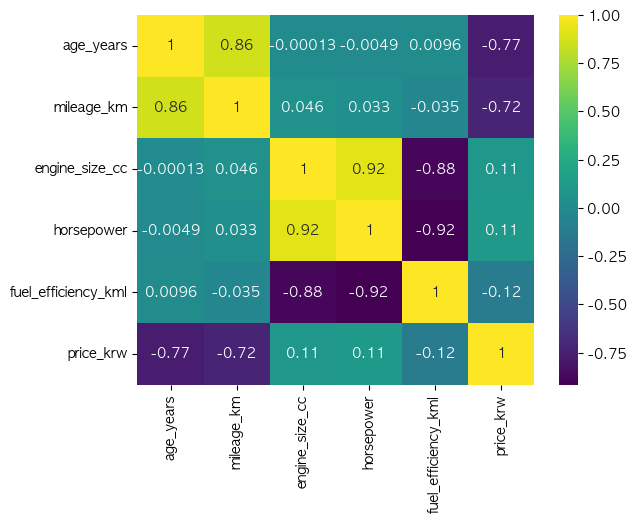

In [64]:
heat = q7_df.corr()
sns.heatmap(heat, annot=True, cmap='viridis')